**Github** : https://github.com/OzgurYldrm/AI-ML-Course     
**Youtube** : https://www.youtube.com/@F%C3%BCt%C3%BCrist_AIntelligence

**Not**: Kodların hata vermeden çalışması için *Python Notebook* ile aynı dizinde *image.jpg* isimli bir resmin bulunması gerekir. Dilerseniz *github* içerisinde paylaşılan resmi bilgisayarınızda aynı dizine koyabilir veya *colab*'e yükleyebilirsiniz.

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Image Data - Color Spaces

In [ ]:
img = cv2.imread("image.jpg") #BGR formatında gelir

img_RGB = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) #RGB formatına dönüştürdük

In [8]:
print(img[0][0])
print(img_RGB[0][0])

[111 145 145]
[145 145 111]


In [ ]:
#cv2.imshow("Window Name", img)
#cv2.waitKey(0)
#cv2.destroyAllWindows()

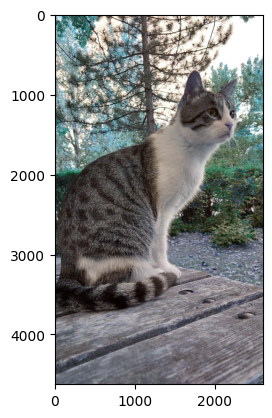

In [9]:
plt.imshow(img)

In [10]:
print(img.shape)
print(img)

(4624, 2604, 3)
[[[111 145 145]
  [130 164 164]
  [147 181 180]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[109 143 143]
  [127 161 161]
  [142 176 175]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[ 67 102 105]
  [ 97 132 135]
  [123 159 159]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 ...

 [[ 98 104 115]
  [101 107 118]
  [101 107 118]
  ...
  [144 158 176]
  [138 152 170]
  [133 147 165]]

 [[105 109 120]
  [107 111 122]
  [106 110 121]
  ...
  [140 154 172]
  [131 146 165]
  [134 149 168]]

 [[104 108 119]
  [102 106 117]
  [100 104 115]
  ...
  [136 150 168]
  [121 136 155]
  [128 143 162]]]


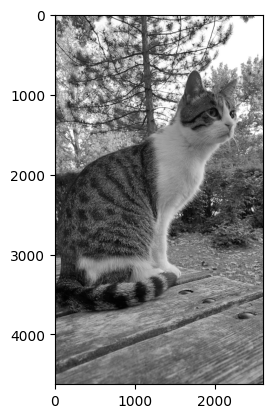

In [13]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(gray,cmap="gray")

# RGB2Gray

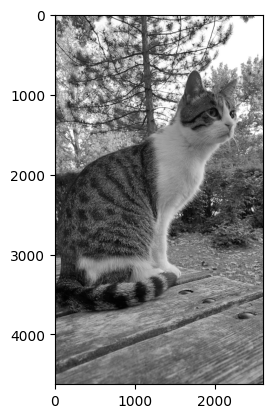

In [14]:
img = cv2.imread("image.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(gray,cmap="gray")

In [15]:
for i in range(3):
    for j in range(3):
        print(img[i][j] , gray[i][j])

[111 145 145] 141
[130 164 164] 160
[147 181 180] 177
[109 143 143] 139
[127 161 161] 157
[142 176 175] 172
[ 67 102 105] 99
[ 97 132 135] 129
[123 159 159] 155


# Thresholding

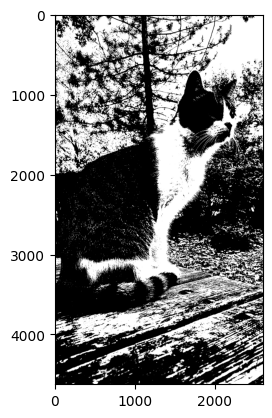

In [6]:
img = cv2.imread("image.jpg", cv2.IMREAD_GRAYSCALE)

ret, thresh = cv2.threshold(
    img,
    127,                 # threshold değeri
    255,                 # max value
    cv2.THRESH_BINARY    # threshold tipi
)
plt.imshow(thresh,cmap="gray")

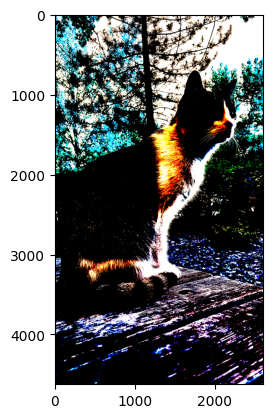

In [7]:
img = cv2.imread("image.jpg")

b,g,r = cv2.split(img)

_, r_th = cv2.threshold(r,150,255,cv2.THRESH_BINARY)
_, g_th = cv2.threshold(g,150,255,cv2.THRESH_BINARY)
_, b_th = cv2.threshold(b,150,255,cv2.THRESH_BINARY)

result = cv2.merge([b_th,g_th,r_th])
plt.imshow(result)

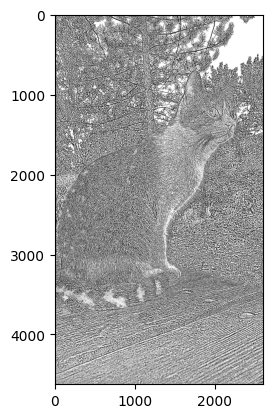

In [9]:
img = cv2.imread("image.jpg", cv2.IMREAD_GRAYSCALE)

th_mean = cv2.adaptiveThreshold(
    img,
    255,                    # max value
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    11,                     # block size (tek sayı olmalı)
    2                       # C sabiti
)

plt.imshow(th_mean,cmap="gray")


# Erosion-Dilation

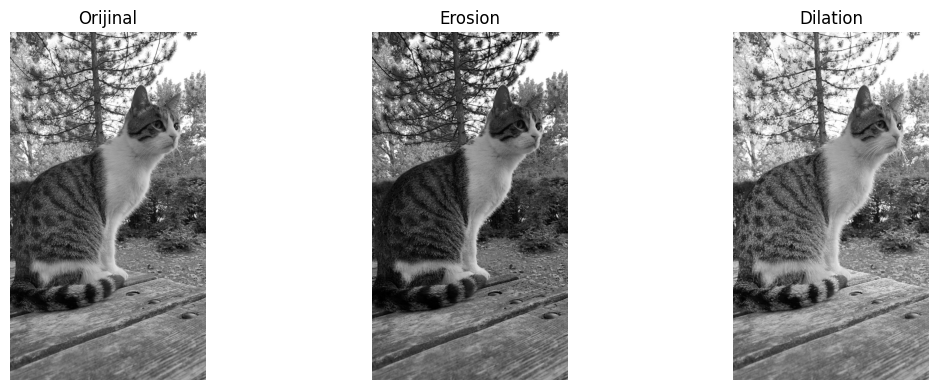

In [21]:
img = cv2.imread("image.jpg", cv2.IMREAD_GRAYSCALE)

kernel = np.ones((5,5), np.uint8)

erosion = cv2.erode(img, kernel, iterations=1)
dilation = cv2.dilate(img, kernel, iterations=1)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Orijinal")
plt.imshow(img, cmap="gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Erosion")
plt.imshow(erosion, cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Dilation")
plt.imshow(dilation, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()

# Convolution Operation

In [3]:
img = cv2.imread("image.jpg") #BGR formatında gelir

img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

kernel = np.array([
        [1, 0, -1],
        [1, 0, -1],
        [1,0,-1],
    ], dtype=np.float32)

out_h = img.shape[0] - kernel.shape[0] + 1
out_w = img.shape[1] - kernel.shape[1] + 1

output = np.zeros((out_h, out_w), dtype=np.float32)

for i in range(out_h):
    for j in range(out_w):
        region = img[i:i+3, j:j+3]
        output[i,j] = np.sum(region * kernel)

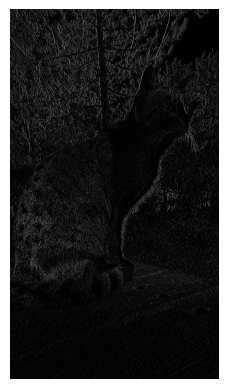

In [4]:
plt.imshow(output,cmap="gray",vmin=0, vmax=255)
plt.axis("off")
plt.show()

In [5]:
img = np.array([
    [50, 50, 50, 0, 0, 0],
    [50, 50, 50, 0, 0, 0],
    [50, 50, 50, 0, 0, 0],
    [50, 50, 50, 0, 0, 0],
    [50, 50, 50, 0, 0, 0],
    [50, 50, 50, 0, 0, 0]
], dtype=np.float32)

kernel = np.array([
        [1, 0, -1],
        [1, 0, -1],
        [1,0,-1],
    ], dtype=np.float32)

out_h = img.shape[0] - kernel.shape[0] + 1
out_w = img.shape[1] - kernel.shape[1] + 1

output = np.zeros((out_h, out_w), dtype=np.float32)

for i in range(out_h):
    for j in range(out_w):
        region = img[i:i+3, j:j+3]
        output[i,j] = np.sum(region * kernel)

print("Input Image:\n", img)
print("Convolved Output:\n", output)

Input Image:
 [[50. 50. 50.  0.  0.  0.]
 [50. 50. 50.  0.  0.  0.]
 [50. 50. 50.  0.  0.  0.]
 [50. 50. 50.  0.  0.  0.]
 [50. 50. 50.  0.  0.  0.]
 [50. 50. 50.  0.  0.  0.]]
Convolved Output:
 [[  0. 150. 150.   0.]
 [  0. 150. 150.   0.]
 [  0. 150. 150.   0.]
 [  0. 150. 150.   0.]]


# Blurring - Smothing

In [13]:
import numpy as np

I = np.array([
    [10, 20, 30, 40],
    [50, 60, 70, 80],
    [120, 110, 100, 90],
    [140, 130, 150, 160]
], dtype=np.float32)

kernel_size = 3
kernel = np.ones((kernel_size, kernel_size), dtype=np.float32) / 9

padded = np.pad(I, pad_width=1, mode='constant', constant_values=0)

blurred = np.zeros_like(I)

for i in range(I.shape[0]):
    for j in range(I.shape[1]):
        window = padded[i:i+kernel_size, j:j+kernel_size]
        blurred[i,j] = np.sum(window * kernel)

print("Original Image:\n", I)
print("\nBlurred Image (Mean Blur):\n", blurred)

Original Image:
 [[ 10.  20.  30.  40.]
 [ 50.  60.  70.  80.]
 [120. 110. 100.  90.]
 [140. 130. 150. 160.]]

Blurred Image (Mean Blur):
 [[ 15.555555  26.666668  33.333332  24.444447]
 [ 41.11111   63.333332  66.666664  45.555557]
 [ 67.77778  103.333336 105.55556   72.22222 ]
 [ 55.555557  83.33333   82.22222   55.555557]]


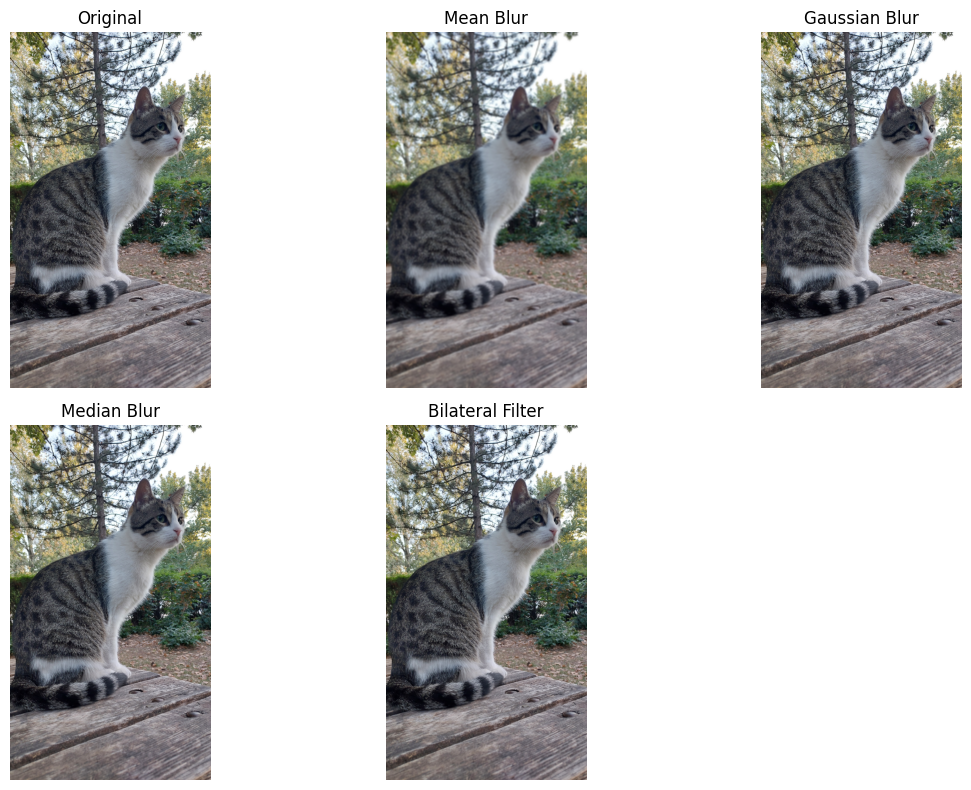

In [15]:
img_bgr = cv2.imread("image.jpg")
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

blur_mean = cv2.blur(img_rgb, (25,25)) # Mean Blur (Average Filter)

blur_gaussian = cv2.GaussianBlur(img_rgb, (5,5), 0) # Gaussian Blur

blur_median = cv2.medianBlur(img_rgb, 5) # Median Blur

blur_bilateral = cv2.bilateralFilter(img_rgb, 9, 75, 75) # Bilateral Filter (edge korur)

plt.figure(figsize=(12,8))

titles = [
    "Original",
    "Mean Blur",
    "Gaussian Blur",
    "Median Blur",
    "Bilateral Filter"
]

images = [
    img_rgb,
    blur_mean,
    blur_gaussian,
    blur_median,
    blur_bilateral
]

for i in range(5):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()


# Conv Layer

In [6]:
import torch
import torch.nn as nn

x = torch.randn(1, 3, 32, 32) # (Batch, Channel, Height, Width)

conv = nn.Conv2d( # Conv2D layer
    in_channels=3,
    out_channels=8,
    kernel_size=3,
    stride=1,
    padding=1
)

y = conv(x)

print("Input shape :", x.shape)
print("Output shape:", y.shape)

Input shape : torch.Size([1, 3, 32, 32])
Output shape: torch.Size([1, 8, 32, 32])


In [34]:
x = torch.randn(1, 1, 4, 5, 5)  # (N, C, D, H, W)

conv3d = nn.Conv3d(
    in_channels=1,
    out_channels=2,    
    kernel_size=(2,3,3),# (D,H,W)
    stride=1,
    padding=0,
    bias=False
)

y = conv3d(x)

print("Input shape :", x.shape)
print("Output shape:", y.shape)

Input shape : torch.Size([1, 1, 4, 5, 5])
Output shape: torch.Size([1, 2, 3, 3, 3])


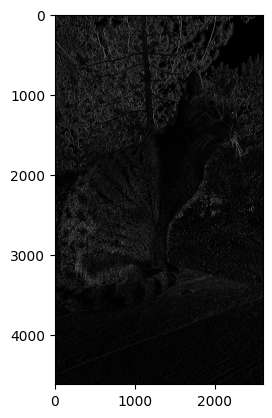

In [9]:
img = cv2.imread("image.jpg", cv2.IMREAD_GRAYSCALE)

conv = nn.Conv2d(1,1,3,bias=False,padding=0)

kernel = torch.tensor([
    [[[1,0,-1],
      [1,0,-1],
      [1,0,-1]]]
], dtype=torch.float32)

kernel = torch.flip(kernel, [2,3])

with torch.no_grad():
    conv.weight.copy_(kernel)

img_torch = torch.from_numpy(img).float() / 255.0
img_torch = img_torch.unsqueeze(0).unsqueeze(0)

out = conv(img_torch).squeeze().detach().cpu().numpy()
plt.imshow(out,cmap="gray",vmin=0,vmax=1)

# Pooling

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Dummy input
x = torch.tensor([
    [[
        [1., 2., 3., 4.],
        [5., 6., 7., 8.],
        [9.,10.,11.,12.],
        [13.,14.,15.,16.]
    ]]
])  # shape: (1,1,4,4)

In [13]:
max_pool = nn.MaxPool2d(kernel_size=2, stride=2)
y_max = max_pool(x)
print("Max Pooling:\n", y_max)

Max Pooling:
 tensor([[[[ 6.,  8.],
          [14., 16.]]]])


In [14]:
avg_pool = nn.AvgPool2d(kernel_size=2, stride=2)
y_avg = avg_pool(x)
print("Average Pooling:\n", y_avg)

Average Pooling:
 tensor([[[[ 3.5000,  5.5000],
          [11.5000, 13.5000]]]])


In [15]:
y_sum = y_avg * (2*2)
print("Sum Pooling:\n", y_sum)

Sum Pooling:
 tensor([[[[14., 22.],
          [46., 54.]]]])


# CNN

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1) # 1. Convolution layer: input 1 channel, output 16 channel, kernel 3x3
        
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1) # 2. Convolution layer: input 16 channel, output 32 channel, kernel 3x3
        
        self.fc1 = nn.Linear(32*7*7, 128) # Fully connected layer: 32*7*7 -> 128
        
        self.fc2 = nn.Linear(128, 10) # Output layer: 128 -> 10 classes
        
        self.pool = nn.MaxPool2d(2, 2) # Max pooling

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # [batch, 16, 14, 14]
        x = self.pool(F.relu(self.conv2(x)))  # [batch, 32, 7, 7]
        x = x.view(-1, 32*7*7)                # Flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleCNN()
print(model)

x = torch.randn(8, 1, 28, 28) #Modeli test etmek için uygun boyutlarda random input oluşturduk
output = model(x)
print("Output shape:", output.shape)  # [8, 10]

SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)
Output shape: torch.Size([8, 10])


# Finetuning

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision import models

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),     # AlexNet input
    transforms.Grayscale(num_output_channels=3),  # 1ch → 3ch
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])
])

In [4]:
train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform)

test_dataset = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

In [5]:
model = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)

for param in model.features.parameters(): #Freeze
    param.requires_grad = False

model.classifier[6] = nn.Linear(4096, 10) # Son layer değiştir

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [6]:
epochs = 3

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1} Loss: {running_loss/len(train_loader):.4f}")

Epoch 1 Loss: 0.1213
Epoch 2 Loss: 0.0506
Epoch 3 Loss: 0.0384


In [7]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Test Accuracy:", 100 * correct / total)

Test Accuracy: 98.85


# AlexNet

Top 5 Tahmin:
Madagascar cat 0.4515140950679779
Siberian husky 0.07845457643270493
koala 0.05978843569755554
Egyptian cat 0.05294916406273842
lynx 0.048454828560352325


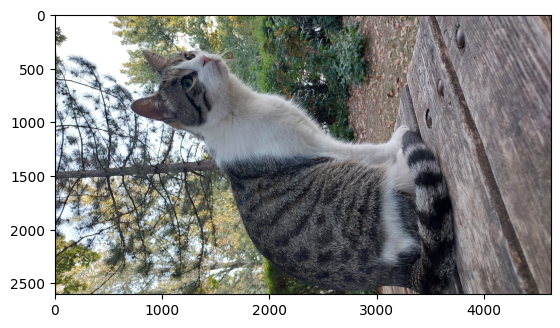

In [8]:
import torch
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import urllib.request

model = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1) #233 MB
model.eval()


url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
urllib.request.urlretrieve(url, "imagenet_classes.txt")

with open("imagenet_classes.txt") as f:
    classes = [line.strip() for line in f.readlines()]

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

img = Image.open("image.jpg").convert("RGB")
input_tensor = transform(img).unsqueeze(0)

with torch.no_grad():
    outputs = model(input_tensor)
    probs = torch.nn.functional.softmax(outputs[0], dim=0)

top5_prob, top5_catid = torch.topk(probs, 5)

print("Top 5 Tahmin:")
for i in range(top5_prob.size(0)):
    print(classes[top5_catid[i]], float(top5_prob[i]))

plt.imshow(img)

# Inception

In [8]:
import torch
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn.functional as F
from PIL import Image

weights = models.Inception_V3_Weights.DEFAULT
model = models.inception_v3(weights=weights)
model.eval()

class_names = weights.meta["categories"]

transform = transforms.Compose([
    transforms.Resize(342),
    transforms.CenterCrop(299),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

img = Image.open("image.jpg").convert("RGB")
x = transform(img).unsqueeze(0)

with torch.no_grad():
    out = model(x)

probs = F.softmax(out, dim=1)

top5_prob, top5_idx = torch.topk(probs, 5)

top5_prob = top5_prob.squeeze(0)
top5_idx = top5_idx.squeeze(0)

print("Top-5 Predictions:")
for i in range(5):
    idx = top5_idx[i].item()
    name = class_names[idx]
    prob = top5_prob[i].item()

    print(f"{i+1}. index: {idx} | class: {name} | prob: {prob:.4f}")

Top-5 Predictions:
1. index: 281 | class: tabby | prob: 0.1046
2. index: 282 | class: tiger cat | prob: 0.1035
3. index: 285 | class: Egyptian cat | prob: 0.0917
4. index: 383 | class: Madagascar cat | prob: 0.0302
5. index: 23 | class: vulture | prob: 0.0158


# VGG


Top-5 Tahmin:
tiger : 0.2590
tiger cat : 0.2215
Madagascar cat : 0.2043
cougar : 0.0585
Egyptian cat : 0.0309


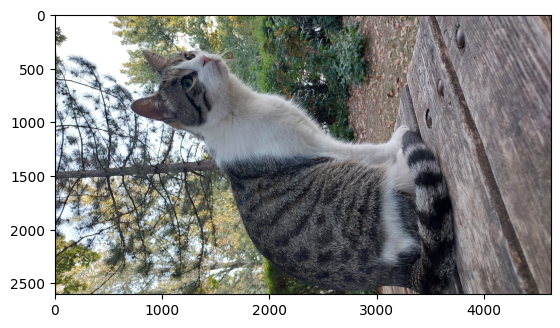

In [9]:
import torch
from torchvision import models, transforms
from PIL import Image

weights = models.VGG16_Weights.DEFAULT
model = models.vgg16(weights=weights)

model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

preprocess = weights.transforms()

img = Image.open("image.jpg").convert("RGB")

input_tensor = preprocess(img)
input_batch = input_tensor.unsqueeze(0).to(device)  # batch dimension

with torch.no_grad():
    outputs = model(input_batch)
    probs = torch.nn.functional.softmax(outputs[0], dim=0)

categories = weights.meta["categories"]
top5_prob, top5_catid = torch.topk(probs, 5)

print("\nTop-5 Tahmin:")
for i in range(top5_prob.size(0)):
    print(f"{categories[top5_catid[i]]} : {top5_prob[i].item():.4f}")
plt.imshow(img)

# ResNet

In [11]:
import torch
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import torch.nn.functional as F

weights = models.ResNet50_Weights.DEFAULT
model = models.resnet50(weights=weights)
model.eval()
class_names = weights.meta["categories"]

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

img = Image.open("image.jpg").convert("RGB")
x = transform(img).unsqueeze(0)

with torch.no_grad():
    out = model(x)

probs = F.softmax(out, dim=1)
top5_prob, top5_idx = torch.topk(probs, 5)
top5_prob = top5_prob.squeeze(0)
top5_idx = top5_idx.squeeze(0)

print("Top-5 Predictions:")
for i in range(5):
    idx = top5_idx[i].item()
    name = class_names[idx]
    prob = top5_prob[i].item()

    print(f"{i+1}. index: {idx} | class: {name} | prob: {prob:.4f}")


Top-5 Predictions:
1. index: 282 | class: tiger cat | prob: 0.2902
2. index: 281 | class: tabby | prob: 0.2320
3. index: 285 | class: Egyptian cat | prob: 0.0552
4. index: 287 | class: lynx | prob: 0.0140
5. index: 284 | class: Siamese cat | prob: 0.0083


# MobileNet

In [13]:
import torch
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn.functional as F
from PIL import Image

weights = models.MobileNet_V3_Large_Weights.DEFAULT
model = models.mobilenet_v3_large(weights=weights)
model.eval()

class_names = weights.meta["categories"]

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

img = Image.open("image.jpg").convert("RGB")
x = transform(img).unsqueeze(0)

with torch.no_grad():
    out = model(x)

probs = F.softmax(out, dim=1)


top5_prob, top5_idx = torch.topk(probs, 5)

top5_prob = top5_prob.squeeze(0)
top5_idx = top5_idx.squeeze(0)

print("Top-5 Predictions:")
for i in range(5):
    idx = top5_idx[i].item()
    name = class_names[idx]
    prob = top5_prob[i].item()

    print(f"{i+1}. index: {idx} | class: {name} | prob: {prob:.4f}")


Top-5 Predictions:
1. index: 282 | class: tiger cat | prob: 0.3545
2. index: 281 | class: tabby | prob: 0.1455
3. index: 285 | class: Egyptian cat | prob: 0.0951
4. index: 249 | class: malamute | prob: 0.0455
5. index: 248 | class: Eskimo dog | prob: 0.0350


# EfficientNet

In [3]:
import torch
import torchvision.transforms as transforms
from torchvision import models
from PIL import Image
import urllib.request
import json

model = models.efficientnet_b0(weights="IMAGENET1K_V1")
model.eval()

url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
urllib.request.urlretrieve(url, "imagenet_classes.txt")

with open("imagenet_classes.txt") as f:
    classes = [line.strip() for line in f.readlines()]

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

image = Image.open("image.jpg").convert("RGB")
input_tensor = transform(image).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)

probs = torch.softmax(output, dim=1)

top5_prob, top5_idx = torch.topk(probs, 5)

print("\nTop 5 Predictions:\n")

for i in range(5):
    idx = top5_idx[0][i].item()
    prob = top5_prob[0][i].item()
    label = classes[idx]

    print(f"{i+1}. {label}  ->  {prob:.4f}")


Top 5 Predictions:

1. Madagascar cat  ->  0.1549
2. tiger cat  ->  0.1209
3. tabby  ->  0.0887
4. Egyptian cat  ->  0.0536
5. snow leopard  ->  0.0529


# Data Augmentation

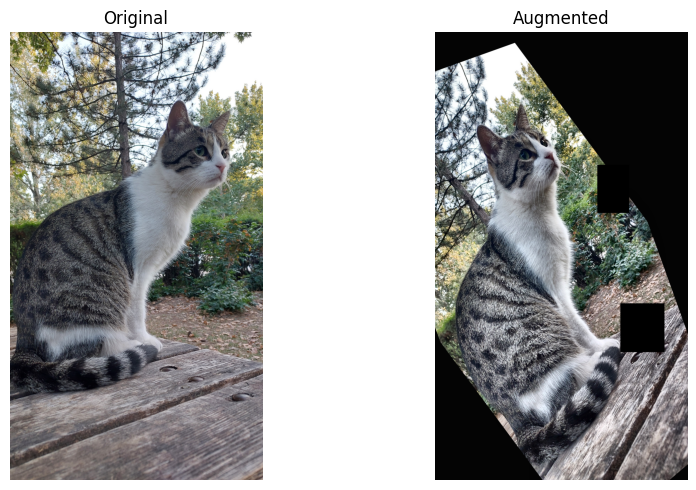

In [18]:
import cv2
import albumentations as A
import matplotlib.pyplot as plt

image = cv2.imread("image.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

transform = A.Compose([

    # -------------------
    # GEOMETRİK
    # -------------------
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=30, p=0.4),
    A.RandomScale(scale_limit=0.3, p=0.4),
    A.ShiftScaleRotate(
        shift_limit=0.1,
        scale_limit=0.1,
        rotate_limit=20,
        p=0.4
    ),

    # -------------------
    # COLOR / INTENSITY
    # -------------------
    A.RandomBrightnessContrast(p=0.5),
    A.HueSaturationValue(p=0.4),
    A.RGBShift(p=0.3),
    A.RandomGamma(p=0.3),
    A.CLAHE(p=0.3),

    # -------------------
    # NOISE / BLUR
    # -------------------
    A.GaussNoise(p=0.3),
    A.GaussianBlur(p=0.2),
    A.MotionBlur(p=0.2),

    # -------------------
    # OCCLUSION
    # -------------------
    A.CoarseDropout(p=0.3),

    # -------------------
    # WEATHER
    # -------------------
    A.RandomFog(p=0.2),
    A.RandomRain(p=0.2),
    A.RandomShadow(p=0.2),
])

result = transform(image=image)
augmented_image = result["image"]

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(augmented_image)
plt.title("Augmented")
plt.axis("off")

plt.tight_layout()
plt.show()
